Problem Statement
Build an Image Classifier with CNN —Load the CSV file (a random 5,000-row sample is plenty), separate the label column, reshape the remaining 784 pixel columns to 28×28×1 per row, and normalize pixel values to 0–1 (divide by 255). Build this exact CNN in Keras: Conv2D(32, 3x3, activation="relu") → MaxPooling2D → Conv2D(64, 3x3, activation="relu") → MaxPooling2D → Flatten → Dense(64, activation="relu") → Dense(n_classes, activation="softmax"). Train for 5 epochs and report test accuracy. Display 5 sample test images next to their true and predicted labels.
https://www.kaggle.com/datasets/oddrationale/mnist-in-csv

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Load train and test datasets

In [2]:
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


Take 5,000 random training rows

In [3]:
train_df = train_df.sample(n=5000, random_state=42)

print(train_df.shape)

(5000, 785)


Separate X and y


In [4]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

In [5]:
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5000, 784)
y_train: (5000,)
X_test: (10000, 784)
y_test: (10000,)


Reshape the images

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(5000, 28, 28, 1)
(10000, 28, 28, 1)


Normalize
Pixel values are originally 0–255.
Convert them to 0–1:

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

Find number of classes

In [9]:
n_classes = len(np.unique(y_train))

print("Number of classes:", n_classes)

Number of classes: 10


Build the  CNN

In [10]:
model = Sequential([

    Conv2D(32, (3,3), activation="relu",
           input_shape=(28,28,1)),

    MaxPooling2D(),

    Conv2D(64, (3,3), activation="relu"),

    MaxPooling2D(),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(n_classes, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train for 5 epochs

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7623 - loss: 0.7698 - val_accuracy: 0.9340 - val_loss: 0.2223
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9473 - loss: 0.1867 - val_accuracy: 0.9510 - val_loss: 0.1499
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9695 - loss: 0.1102 - val_accuracy: 0.9610 - val_loss: 0.1304
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9743 - loss: 0.0816 - val_accuracy: 0.9670 - val_loss: 0.1099
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9833 - loss: 0.0547 - val_accuracy: 0.9600 - val_loss: 0.1243


Test the CNN

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9573 - loss: 0.1425
Test Accuracy: 95.73%


Make predictions

In [14]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [15]:
print("True labels:     ", y_test[:5])
print("Predicted labels:", predicted_labels[:5])

True labels:      [7 2 1 0 4]
Predicted labels: [7 2 1 0 4]


Display 5 test images

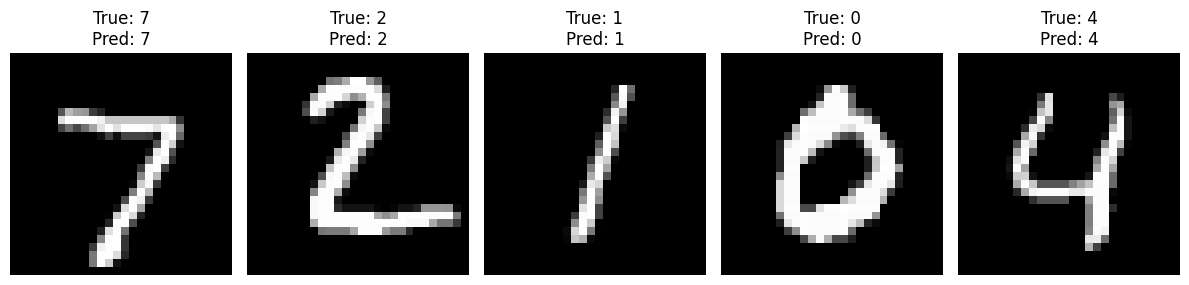

In [16]:
plt.figure(figsize=(12, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {y_test[i]}\nPred: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()